In [46]:
import pandas as pd
from textblob import TextBlob

In [47]:
df=pd.read_csv("/content/chatgpt_reviews.csv")

In [48]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [49]:
df.isnull().sum()

,0
Review Id,0
Review,2
Ratings,0
Review Date,0


In [50]:
df=df.ffill()

In [51]:
df.isnull().sum()

,0
Review Id,0
Review,0
Ratings,0
Review Date,0


In [52]:
df['Review']

,Review
0,good
1,good
2,nice app
3,"nice, ig"
4,"this is a great app, the bot is so accurate to..."
...,...
81408,fast and more than 85% accurate
81409,That's app very very very usefull🥰🥰🥰🥰🥰🥰😘😘😍😍😍😍🎉...
81410,good for searching what your looking for😁👍
81411,Whenever I restrict data of play store to save...


In [53]:
import re
from nltk.stem import WordNetLemmatizer
Lemmatizer=WordNetLemmatizer()
from nltk.corpus import stopwords

In [54]:
sentence=df['Review'].values
sentence

array(['good', 'good', 'nice app', ...,
       'good for searching what your looking for😁👍',
       "Whenever I restrict data of play store to save data,Chatgpt says network problem, what connection is between play store and chatgpt Now it's fully not working. And now voice assist also not working.",
       'better choice'], dtype=object)

In [55]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [56]:
def clean_text(sentence1):
    corpu=[]
    for i in range(len(sentence1)):
        review=re.sub('[^a-zA-Z]',' ',sentence1[i])#the line explain that sentence which remove special letter or symbol other then the alphapet
        review=review.lower()
        review=review.split()
        review=[Lemmatizer.lemmatize(word) for word in review if not word in set(stopwords.words('english'))]
        review=' '.join(review)
        corpu.append(review)
    return corpu

In [57]:
df['clean_text']=clean_text(sentence)

In [58]:
df['clean_text']

,clean_text
0,good
1,good
2,nice app
3,nice ig
4,great app bot accurate anything give tip gamin...
...,...
81408,fast accurate
81409,app usefull
81410,good searching looking
81411,whenever restrict data play store save data ch...


In [59]:
def get_sentiment_details(corpus):
    polarities = []
    subjectivities = []
    sentiments = []

    for my_texts in corpus:
        analysis = TextBlob(my_texts)
        polarity = analysis.sentiment.polarity
        subjectivity = analysis.sentiment.subjectivity

        polarities.append(polarity)
        subjectivities.append(subjectivity)

        if polarity > 0:
            sentiments.append("positive")
        elif polarity < 0:
            sentiments.append("negative")
        else:
            sentiments.append("neutral")

    return polarities, subjectivities, sentiments


# Assign the results back to your DataFrame
df["polarity"], df["subjectivity"], df["sentiment"] = get_sentiment_details(
    df["clean_text"]
)

In [60]:
df

,Review Id,Review,Ratings,Review Date,clean_text,polarity,subjectivity,sentiment
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,good,0.7000,0.600000,positive
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,good,0.7000,0.600000,positive
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,nice app,0.6000,1.000000,positive
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,nice ig,0.6000,1.000000,positive
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,great app bot accurate anything give tip gamin...,0.3375,0.480449,positive
...,...,...,...,...,...,...,...,...
81408,dd8da9a9-b457-4485-addf-49c1f1b51ffe,fast and more than 85% accurate,5,2024-05-14 13:27:09,fast accurate,0.3000,0.616667,positive
81409,fb88382b-4f10-473e-b03b-58a5ca05fe2f,That's app very very very usefull🥰🥰🥰🥰🥰🥰😘😘😍😍😍😍🎉...,5,2024-05-14 13:26:41,app usefull,0.0000,0.000000,neutral
81410,cba105dd-d865-4bec-bfb8-a2140d81e7ee,good for searching what your looking for😁👍,4,2024-05-14 13:26:03,good searching looking,0.7000,0.600000,positive
81411,945d449a-698f-4d64-9c4e-f5c1f88e4613,Whenever I restrict data of play store to save...,2,2024-05-14 13:25:09,whenever restrict data play store save data ch...,0.0000,0.000000,neutral


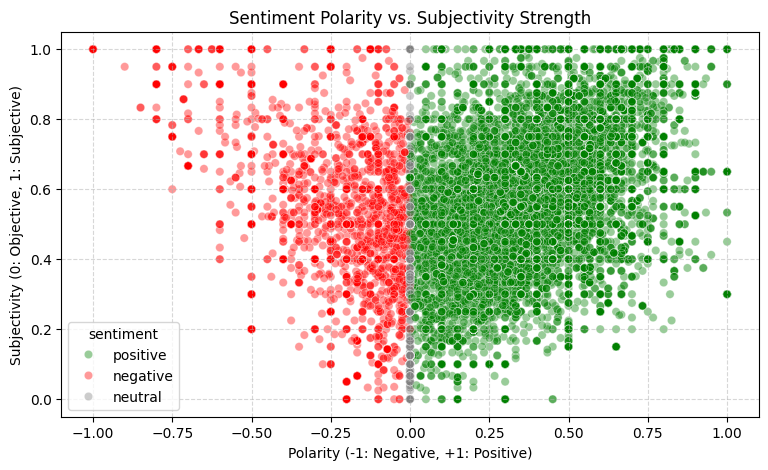

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="polarity",
    y="subjectivity",
    hue="sentiment",
    palette={"positive": "green", "neutral": "gray", "negative": "red"},
    alpha=0.4,
)

plt.title("Sentiment Polarity vs. Subjectivity Strength")
plt.xlabel("Polarity (-1: Negative, +1: Positive)")
plt.ylabel("Subjectivity (0: Objective, 1: Subjective)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

/tmp/ipykernel_2149/3723793286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


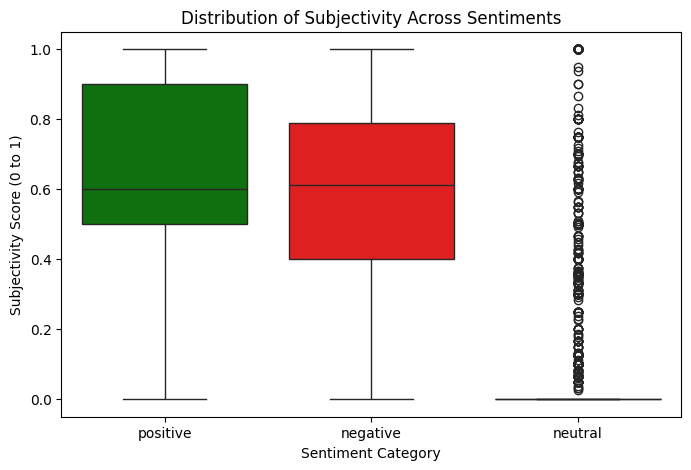

In [64]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="sentiment",
    y="subjectivity",
    palette={"positive": "green", "neutral": "gray", "negative": "red"},
)

plt.title("Distribution of Subjectivity Across Sentiments")
plt.xlabel("Sentiment Category")
plt.ylabel("Subjectivity Score (0 to 1)")
plt.show()

/tmp/ipykernel_2149/4240021400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


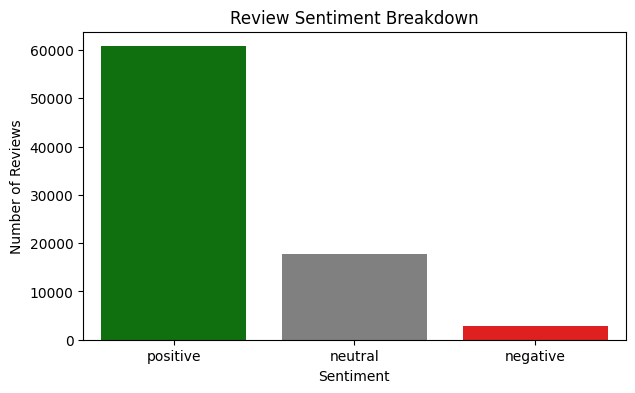

In [65]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x="sentiment",
    palette={"positive": "green", "neutral": "gray", "negative": "red"},
    order=["positive", "neutral", "negative"],
)

plt.title("Review Sentiment Breakdown")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [68]:
df['Review Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 81413 entries, 0 to 81412
Series name: Review Date
Non-Null Count  Dtype 
--------------  ----- 
81413 non-null  object
dtypes: object(1)
memory usage: 636.2+ KB


In [70]:
df['Review Date'][0]

'2024-08-23 19:30:05'

In [73]:
df["Review Date"] = pd.to_datetime(df["Review Date"],errors='coerce')

In [74]:
df["year_month"] = df["Review Date"].dt.to_period("M")

In [75]:
df["year_month"]

,year_month
0,2024-08
1,2024-08
2,2024-08
3,2024-08
4,2024-08
...,...
81408,2024-05
81409,2024-05
81410,2024-05
81411,2024-05


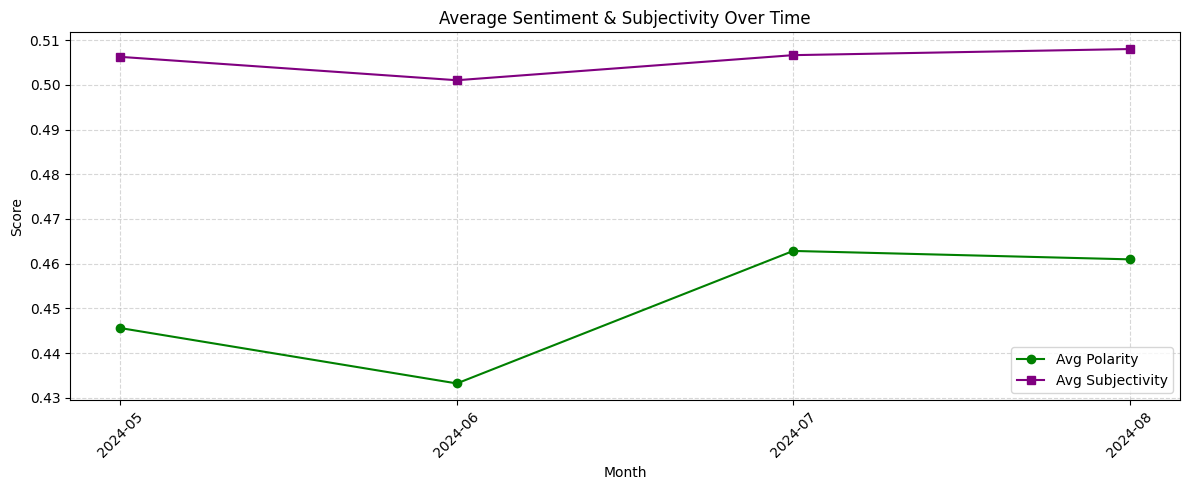

In [76]:
monthly_sentiment = (
    df.groupby("year_month")[["polarity", "subjectivity"]].mean().reset_index()
)
monthly_sentiment["year_month"] = monthly_sentiment["year_month"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sentiment["year_month"],
    monthly_sentiment["polarity"],
    marker="o",
    color="green",
    label="Avg Polarity",
)
plt.plot(
    monthly_sentiment["year_month"],
    monthly_sentiment["subjectivity"],
    marker="s",
    color="purple",
    label="Avg Subjectivity",
)

plt.title("Average Sentiment & Subjectivity Over Time")
plt.xlabel("Month")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

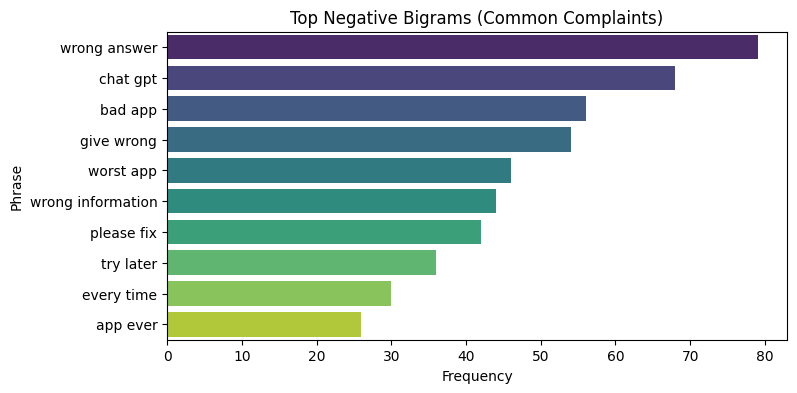

In [77]:
from sklearn.feature_extraction.text import CountVectorizer


def plot_top_ngrams(corpus, n=2, top_k=10, title="Top Bigrams"):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    words_freq = [
        (word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()
    ]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    ngram_df = pd.DataFrame(words_freq, columns=["phrase", "count"])

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=ngram_df, x="count", y="phrase", hue="phrase", palette="viridis"
    )
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Phrase")
    plt.show()


# Run for negative reviews to see top issues
plot_top_ngrams(
    df[df["sentiment"] == "negative"]["clean_text"],
    n=2,
    top_k=10,
    title="Top Negative Bigrams (Common Complaints)",
)